# Cointegration Analysis

In [48]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pairs_teardown.data.loaders import load_or_download
from pairs_teardown.data.clean import handle_missing, align_prices
from pairs_teardown.stats.cointegration import analyze_pair

ALL_TICKERS = ["WM", "RSG", "FOXA", "FOX", "SPY", "VOO"]
prices_raw = load_or_download(ALL_TICKERS, "2015-01-01", "2024-12-31",
                              cache_dir=Path("../data/raw"))

pair_defs = [("WM", "RSG"), ("FOXA", "FOX"), ("SPY", "VOO")]
pairs = {f"{a}/{b}": align_prices(handle_missing(prices_raw[[a, b]]))
         for a, b in pair_defs}

Loading from cache: FOX_FOXA_RSG_SPY_VOO_WM_20150101_20241231.parquet


### Cointegration tests

In [49]:
rows = []
results = {}
for (a, b), (name, df) in zip(pair_defs, pairs.items()):
    res = analyze_pair(df[a], df[b])
    results[name] = res
    rows.append({
        "pair": name,
        "n_days": len(df),
        "hedge_ratio": round(res.hedge_ratio, 4),
        "eg_pvalue": f"{res.eg_pvalue:.4f}",
        "adf_pvalue": f"{res.adf_pvalue:.4f}",
        "cointegrated_5pct": res.eg_pvalue < 0.05,
    })

summary = pd.DataFrame(rows).set_index("pair")
summary

,n_days,hedge_ratio,eg_pvalue,adf_pvalue,cointegrated_5pct
pair,,,,,
WM/RSG,2515,1.0349,0.5629,0.3170,False
FOXA/FOX,1461,1.1100,0.4627,0.2342,False
SPY/VOO,2515,1.0836,0.4884,0.2569,False


### Visualize spread

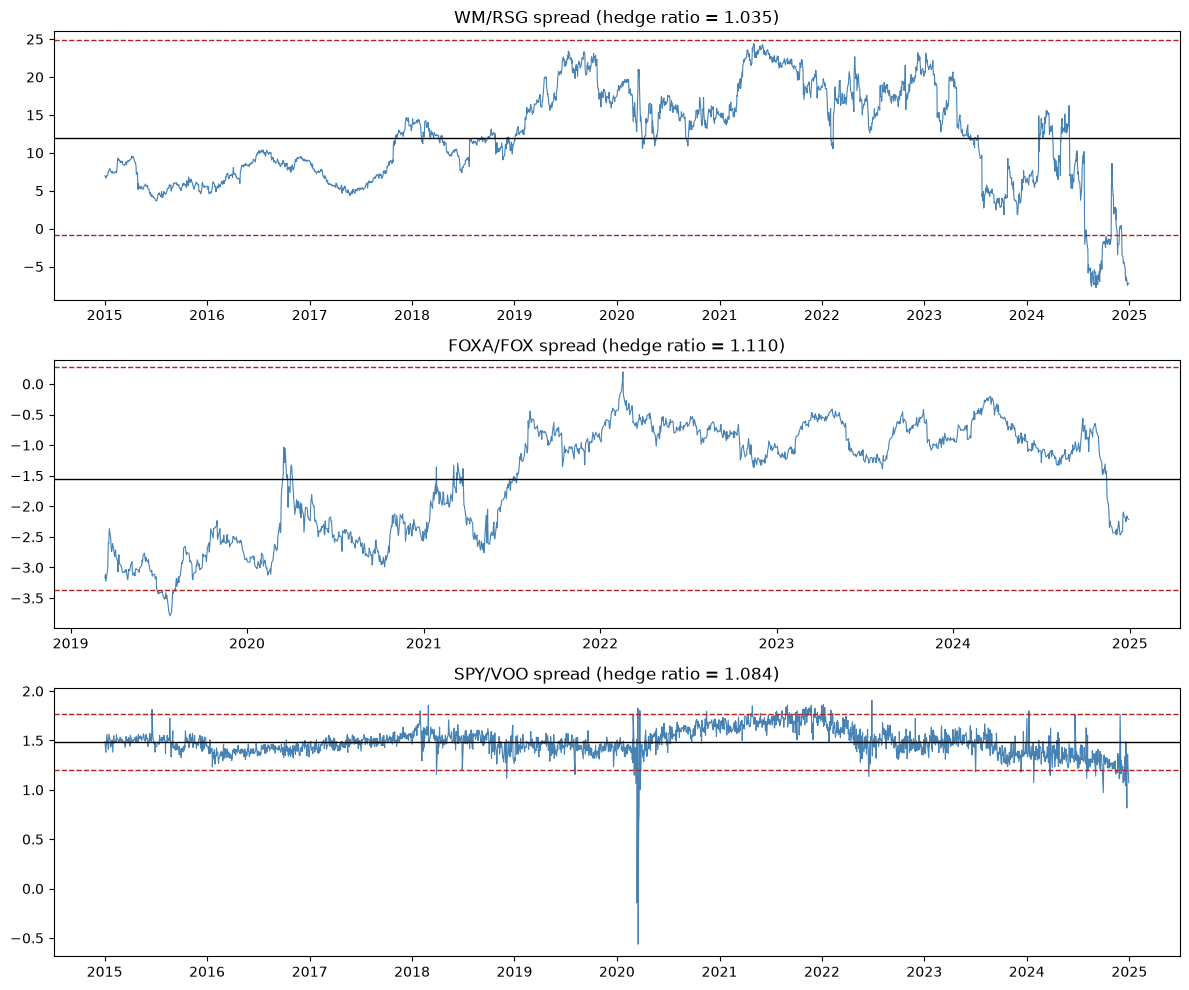

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for ax, (a, b) in zip(axes, pair_defs):
    name = f"{a}/{b}"
    spread = results[name].spread
    mu, sigma = spread.mean(), spread.std()
    ax.plot(pairs[name].index, spread, color="steelblue", lw=0.8)
    ax.axhline(mu, color="black", lw=1)
    ax.axhline(mu + 2 * sigma, color="firebrick", ls="--", lw=1)
    ax.axhline(mu - 2 * sigma, color="firebrick", ls="--", lw=1)
    ax.set_title(f"{name} spread (hedge ratio = {results[name].hedge_ratio:.3f})")
plt.tight_layout()
plt.show()

### Daily return correlations

In [51]:
print("Daily-return correlation:")
for a, b in pair_defs:
    df = pairs[f"{a}/{b}"]
    corr = df[a].pct_change().corr(df[b].pct_change())
    print(f"  {a}/{b}: {corr:.3f}")

Daily-return correlation:
  WM/RSG: 0.859
  FOXA/FOX: 0.988
  SPY/VOO: 0.999


### Using log prices

In [52]:
rows = []
results = {}
for (a, b), (name, df) in zip(pair_defs, pairs.items()):
    res = analyze_pair(np.log(df[a]), np.log(df[b])) #Log Prices
    results[name] = res
    rows.append({
        "pair": name,
        "n_days": len(df),
        "hedge_ratio": round(res.hedge_ratio, 4),
        "eg_pvalue": f"{res.eg_pvalue:.4f}",
        "adf_pvalue": f"{res.adf_pvalue:.4f}",
        "cointegrated_5pct": res.eg_pvalue < 0.05,
    })

summary = pd.DataFrame(rows).set_index("pair")
summary

,n_days,hedge_ratio,eg_pvalue,adf_pvalue,cointegrated_5pct
pair,,,,,
WM/RSG,2515,0.9336,0.2534,0.1018,False
FOXA/FOX,1461,1.0592,0.5302,0.2877,False
SPY/VOO,2515,0.9950,0.0078,0.0015,True


### Position construction from entry/exit rules

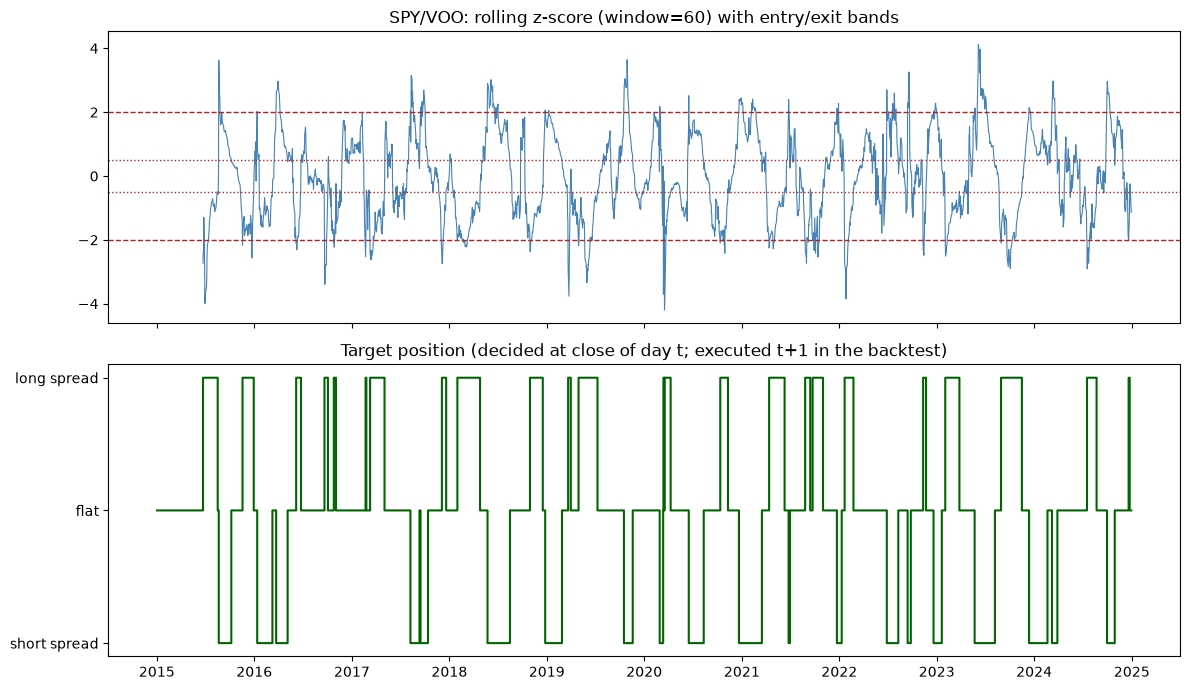

In [53]:
from pairs_teardown.data.clean import to_log_prices
from pairs_teardown.signals.spread import build_rolling_spread, rolling_zscore
from pairs_teardown.signals.rules import target_positions

WINDOW, ENTRY, EXIT = 60, 2.0, 0.5
a, b = "SPY", "VOO"
log_pair = to_log_prices(pairs[f"{a}/{b}"])

spread = build_rolling_spread(log_pair[a], log_pair[b], WINDOW)
z = rolling_zscore(spread, WINDOW)
pos = target_positions(z, ENTRY, EXIT)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(z.index, z, lw=0.8, color="steelblue")
for level, style in [(ENTRY, "--"), (-ENTRY, "--"), (EXIT, ":"), (-EXIT, ":")]:
    ax1.axhline(level, color="firebrick", ls=style, lw=1)
ax1.set_title(f"{a}/{b}: rolling z-score (window={WINDOW}) with entry/exit bands")

ax2.plot(pos.index, pos, drawstyle="steps-post", color="darkgreen")
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["short spread", "flat", "long spread"])
ax2.set_title("Target position (decided at close of day t; executed t+1 in the backtest)")
plt.tight_layout()
plt.show()

### Cointegration tests and spreads using rolling hedge ratios

In [54]:
from pairs_teardown.stats.cointegration import (
    estimate_hedge_ratio, build_spread, adf_pvalue, engle_granger_pvalue
)

rows = []
spreads_static  = {}
spreads_rolling = {}

for a, b in pair_defs:
    name = f"{a}/{b}"
    log_pair = to_log_prices(pairs[name])
    la, lb = log_pair[a], log_pair[b]

    # Static hedge ratio (full in-sample OLS, same as Stage 2)
    static_hr   = estimate_hedge_ratio(la, lb)
    sp_static   = build_spread(la, lb, static_hr)

    # Rolling hedge ratio (60-day trailing OLS)
    sp_rolling  = build_rolling_spread(la, lb, WINDOW)

    spreads_static[name]  = sp_static
    spreads_rolling[name] = sp_rolling

    rows.append({
        "pair":               name,
        #"eg_pvalue":          f"{engle_granger_pvalue(la, lb):.4f}",
        "adf_static_spread":  f"{adf_pvalue(sp_static):.4f}",
        "adf_rolling_spread": f"{adf_pvalue(sp_rolling.dropna()):.4f}",
        #"static_hedge":       round(static_hr, 4),
    })

rows = pd.DataFrame(rows).set_index("pair")
rows

,adf_static_spread,adf_rolling_spread
pair,,
WM/RSG,0.1018,0.0000
FOXA/FOX,0.2877,0.0000
SPY/VOO,0.0015,0.0000


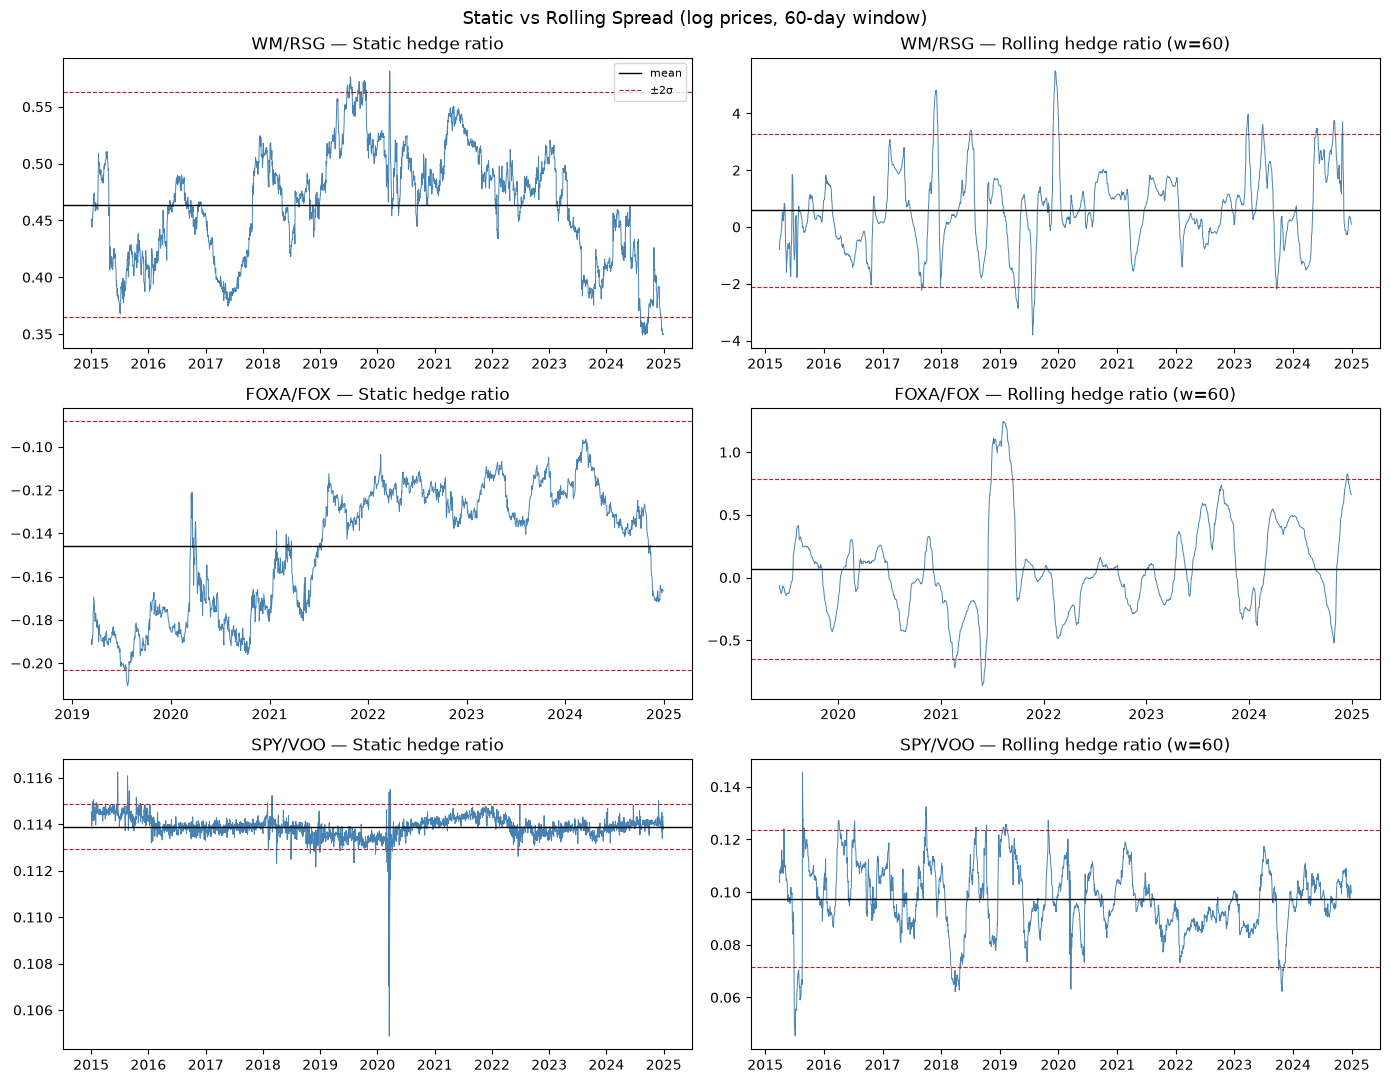

In [55]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle("Static vs Rolling Spread (log prices, 60-day window)", fontsize=13)

for row_idx, (a, b) in enumerate(pair_defs):
    name = f"{a}/{b}"
    idx  = pairs[name].index

    for col_idx, (spread, label) in enumerate([
        (spreads_static[name],  "Static hedge ratio"),
        (spreads_rolling[name], f"Rolling hedge ratio (w={WINDOW})"),
    ]):
        ax  = axes[row_idx][col_idx]
        mu  = spread.mean()
        sig = spread.std()
        ax.plot(idx, spread, lw=0.7, color="steelblue")
        ax.axhline(mu,           color="black",    lw=1.0, label="mean")
        ax.axhline(mu + 2 * sig, color="firebrick", lw=0.8, ls="--", label="±2σ")
        ax.axhline(mu - 2 * sig, color="firebrick", lw=0.8, ls="--")
        ax.set_title(f"{name} — {label}")
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()